# Chapter 7. Explicit Control Laws for Constrained Linear Systems
# 제약 선형 시스템의 명시적 제어법칙

Rawlings, Mayne, Diehl (2017), **2판 1쇄 제7장, 인쇄 pp.451–490**의 한글 해설·실습입니다.
**7.1–7.11 및 모든 하위 절, 총 18개 제목**을 원본 순서로 배치합니다. 본문 pp.451–483, 연습문제 pp.484–488, 참고문헌 pp.489–490입니다.

**학습 목표:** 파라미터 최적화의 해 구조, 활성 제약과 임계 영역, 구간별 아핀 입력과 이차 비용, 동적 계획법(DP), 선형계획법(LP)의 유일성, 오프라인 계산과 온라인 영역 탐색을 연결합니다.

**실행:** Colab에서 `런타임 → 모두 실행`. 처음부터 순서대로 실행하세요. 이전 장이나 저장소 복제 없이 CPU에서 실행합니다. 최초 패키지·한글 글꼴 설치에는 인터넷이 필요합니다.

**범위:** 원본 예제 7.11·7.12의 문제와 임계 영역을 재현합니다. 그 밖의 수치 실습은 직접 설계한 작은 보충 문제입니다. 모든 증명·연습문제 해답을 재현하지 않습니다. 2차원 QP의 영역은 활성 집합과 반평면 교차로 계산하고, 스칼라 DP는 이차 함수 후보의 교점으로 구성합니다. 격자는 검증·시각화에 사용하며 제어법칙을 회귀로 근사하지 않습니다.

**기호:** $x$는 최적화의 파라미터인 현재 상태, $U$는 예측 입력 열, $u$는 첫 입력입니다. 아핀 함수는 $Kx+k$처럼 상수항을 포함합니다. LQ 비용에 계수 $1/2$를 사용합니다. LP 보충 실습은 별도 비용을 명시합니다.

[PPT](https://github.com/JunsPark00/rawlings-model-predictive-control-notes/blob/main/chapter07_explicit_control/slides/chapter07_slides.pptx) · [PDF](https://github.com/JunsPark00/rawlings-model-predictive-control-notes/blob/main/chapter07_explicit_control/slides/chapter07_slides.pdf)

## 실습 환경 준비

한글 글꼴과 수치 패키지를 준비합니다. 계산은 재현 가능한 고정 난수 시드를 사용합니다.

In [1]:
import importlib.util, subprocess, sys

packages = {
    "numpy": "numpy>=2,<3",
    "scipy": "scipy>=1.14,<2",
    "matplotlib": "matplotlib>=3.9,<4",
    "cvxpy": "cvxpy>=1.6,<2",
    "osqp": "osqp>=1,<2",
}
missing = [
    spec for name, spec in packages.items() if importlib.util.find_spec(name) is None
]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
import numpy as np
import scipy
from scipy.linalg import solve_discrete_are, expm
from scipy.signal import cont2discrete
import matplotlib
import matplotlib.pyplot as plt
import cvxpy as cp
from pathlib import Path
import tempfile
import urllib.request
from matplotlib import font_manager

# Colab과 로컬에서 동일하게 한글 그래프를 표시하기 위한 공개 글꼴.
font_dir = Path(tempfile.gettempdir()) / "mpc_korean_fonts"
font_dir.mkdir(exist_ok=True)
font_path = font_dir / "NanumGothic-Regular.ttf"
if not font_path.exists():
    url = "https://raw.githubusercontent.com/google/fonts/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
    with urllib.request.urlopen(url, timeout=60) as response:
        font_path.write_bytes(response.read())
font_manager.fontManager.addfont(str(font_path))
korean_font = font_manager.FontProperties(fname=font_path).get_name()

np.set_printoptions(precision=5, suppress=True)
plt.rcParams.update(
    {
        "figure.figsize": (9, 3.8),
        "axes.grid": True,
        "grid.alpha": 0.22,
        "font.size": 11,
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.family": ["DejaVu Sans", korean_font],
        "mathtext.fontset": "dejavusans",
        "axes.unicode_minus": False,
    }
)
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
CHECKS = {}


def finish_figure(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", dpi=170, bbox_inches="tight")
    plt.show()
    plt.close()


## 7.1 Introduction — 개요

**교재 인쇄 pp.451–452**

보통 MPC는 측정한 상태마다 최적화 문제를 풉니다. 명시적 MPC는 상태를 파라미터로 두고 가능한 상태 영역마다 최적 입력 식을 미리 구합니다. 온라인에서는 상태가 어느 영역에 속하는지 찾고 해당 식의 첫 입력을 계산합니다.

오프라인 계산·저장 부담을 온라인 계산과 교환하는 방식입니다. 모든 문제에 작은 영역 분할이 존재하는 것은 아닙니다. 이 장은 선형 모델, 다면체 제약, 이차 또는 선형 비용에서 얻는 해의 구조를 설명합니다.

## 7.2 Parametric Programming — 파라미터 최적화

**교재 인쇄 pp.452–457**

파라미터 $x$가 달라지면 허용 입력 집합, 최적 입력, 최적 비용이 함께 바뀝니다. $\mathcal X$는 허용 입력이 하나 이상 존재하는 상태들의 집합입니다. 목적함수의 최솟값과 그 값을 만드는 입력 집합을 구분해야 합니다.

보충 문제 $J=x^2+xu+u^2/2$, $|u|\le1$은 입력에 대해 엄격 볼록입니다. 제약 없는 해 $-x$를 입력 구간에 투영하면 세 영역을 얻습니다. 내부의 비용은 $x^2/2$, 바깥의 비용은 $x^2-|x|+1/2$입니다.

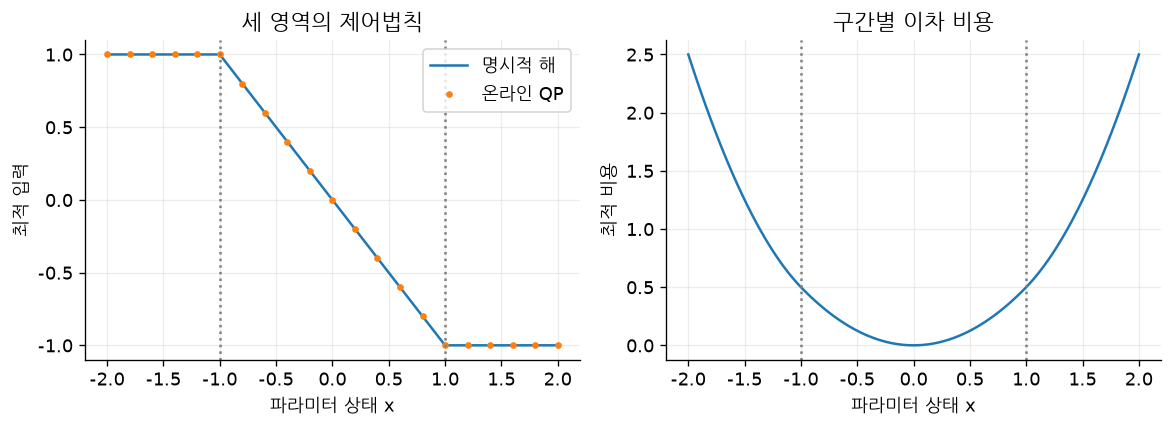

In [2]:
xx = np.linspace(-2, 2, 101)
exact = -np.clip(xx, -1, 1)
u = cp.Variable()
xpar = cp.Parameter()
prob = cp.Problem(
    cp.Minimize(cp.square(xpar) + xpar * u + 0.5 * cp.square(u)), [cp.abs(u) <= 1]
)
computed = []
for x in xx:
    xpar.value = x
    prob.solve(solver=cp.CLARABEL, tol_gap_abs=1e-11, tol_feas=1e-11, tol_gap_rel=1e-11)
    assert prob.status == cp.OPTIMAL
    computed.append(u.value)
record_error = float(np.max(abs(np.array(computed) - exact)))
assert record_error < 2e-5
CHECKS["스칼라 QP 입력 오차"] = record_error
vv = xx**2 + xx * exact + 0.5 * exact**2
fig, ax = plt.subplots(1, 2, figsize=(10, 3.7))
ax[0].plot(xx, exact, label="명시적 해")
ax[0].plot(xx[::5], np.array(computed)[::5], "o", ms=3, label="온라인 QP")
ax[1].plot(xx, vv)
for aa in ax:
    aa.axvline(-1, color="gray", ls=":")
    aa.axvline(1, color="gray", ls=":")
    aa.set_xlabel("파라미터 상태 x")
ax[0].set(ylabel="최적 입력", title="세 영역의 제어법칙")
ax[0].legend()
ax[1].set(ylabel="최적 비용", title="구간별 이차 비용")
finish_figure("scalar_qp")


## 7.3 Parametric Quadratic Programming — 파라미터 이차계획법

**교재 인쇄 pp.457–467**

상태와 입력에 대해 이차인 목적함수와 선형 부등식 제약을 생각합니다. 이 노트북의 표준형은 아래와 같습니다. $H\succ0$이면 각 실행 가능 상태에서 입력 열의 최적해가 유일합니다. 교재는 해의 구조를 설명하기 위해 결합 변수에 대한 볼록성 등 해당 정리의 가정을 추가합니다.

활성 제약을 고정하면 최적성 조건은 선형 방정식입니다. 그 해가 비활성 제약과 승수 부호를 만족하는 파라미터 범위를 계산하면 임계 영역을 얻습니다.

$$
\min_U\;\frac12U^THU+U^TFx+\frac12x^TYx\quad\mathrm{s.t.}\quad GU\le Wx+b
$$

### 7.3.1 Preliminaries — 준비: 다면체와 활성 제약

**교재 인쇄 pp.457–458**

활성 제약은 현재 최적점에서 등호가 되는 부등식입니다. 활성 행의 선형 독립성과 활성 제약 개수는 다른 개념입니다. 퇴화된 점에는 필요 이상의 활성 제약이 존재할 수 있습니다.

**주 실습 모델:** $A=[[0.8,0.2],[0,0.7]]$, $B=[0.2,0.5]^T$, $Q=I$, $R=0.3$, $N=2$. 입력은 $|u|\le0.7$, 상태는 $|x_1|\le2.5$, $|x_2|\le1.5$, 종단 상태는 각 성분의 절댓값이 1 이하입니다. $P$는 $A^TPA-P=-Q$의 해입니다. 초기 상태 상자는 파라미터 영역의 제한으로 따로 적용합니다.

아래 코드는 두 입력 변수에 대해 크기 0–2의 독립 활성 집합을 열거합니다. 종속 활성 제약을 포함한 모든 조합을 역행렬로 풀지는 않습니다. 경계의 중복 표현은 허용하고 입력 일치성을 뒤에서 검사합니다.

In [3]:
from itertools import combinations
from scipy.linalg import block_diag, solve_discrete_lyapunov
from scipy.optimize import linprog
from matplotlib.patches import Polygon


def savefig(fig, name):
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}.png", dpi=170, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def record(name, value, tol=None):
    CHECKS[name] = float(value)
    if tol is not None:
        assert value < tol, (name, value, tol)


# 직접 설계한 2상태 · 1입력 · N=2 보충 모델.
A = np.array([[0.8, 0.2], [0, 0.7]])
B = np.array([[0.2], [0.5]])
Q = np.eye(2)
R = 0.3
P = solve_discrete_lyapunov(A.T, Q)
N = 2
xbound = np.array([2.5, 1.5])
umax = 0.7
Sx = np.vstack([A, A @ A])
Su = np.block([[B, np.zeros((2, 1))], [A @ B, B]])
Qbar = block_diag(Q, P)
H = Su.T @ Qbar @ Su + R * np.eye(N)
F = Su.T @ Qbar @ Sx
Y = Q + Sx.T @ Qbar @ Sx
G = np.vstack([np.eye(N), -np.eye(N), Su[:2], -Su[:2], Su[2:], -Su[2:]])
W = np.vstack([np.zeros((4, 2)), -Sx[:2], Sx[:2], -Sx[2:], Sx[2:]])
b = np.r_[np.full(4, umax), xbound, xbound, np.ones(4)]
record("종단 리아푸노프 등식 잔차", np.max(abs(A.T @ P @ A - P + Q)), 1e-12)
assert np.linalg.eigvalsh(H).min() > 0 and np.max(np.sum(abs(A), axis=1)) <= 1


# 반평면과 다각형의 교차: 격자 회귀 없이 임계 영역을 구성한다.
def clip_polygon(poly, normal, bound, tol=1e-10):
    out = []
    for p, q in zip(poly, np.roll(poly, -1, axis=0)):
        fp = normal @ p - bound
        fq = normal @ q - bound
        if fp <= tol:
            out.append(p)
        if (fp <= tol) != (fq <= tol):
            out.append(p + fp / (fp - fq) * (q - p))
    return np.asarray(out).reshape(-1, 2)


def polygon_area(p):
    return (
        abs(
            np.dot(p[:, 0], np.roll(p[:, 1], -1))
            - np.dot(p[:, 1], np.roll(p[:, 0], -1))
        )
        / 2
    )


regions = []
candidates = 0
for size in range(N + 1):
    for active in combinations(range(len(b)), size):
        candidates += 1
        ids = list(active)
        Ga = G[ids]
        Wa = W[ids]
        ba = b[ids]
        if size and np.linalg.matrix_rank(Ga) < size:
            continue
        M = np.block([[H, Ga.T], [Ga, np.zeros((size, size))]])
        sol = np.linalg.solve(M, np.block([[-F, np.zeros((N, 1))], [Wa, ba[:, None]]]))
        K = sol[:N, :2]
        k = sol[:N, 2]
        L = sol[N:, :2]
        ell = sol[N:, 2]
        Ar = np.vstack([G @ K - W, -L, np.eye(2), -np.eye(2)])
        br = np.r_[b - G @ k, ell, xbound, xbound]
        poly = np.array([[-2.5, -1.5], [2.5, -1.5], [2.5, 1.5], [-2.5, 1.5]])
        for normal, bound in zip(Ar, br):
            poly = clip_polygon(poly, normal, bound)
            if len(poly) < 3:
                break
        if len(poly) < 3 or polygon_area(poly) < 1e-9:
            continue
        Pi = Y + K.T @ H @ K + K.T @ F + F.T @ K
        qi = K.T @ H @ k + F.T @ k
        ri = 0.5 * k @ H @ k
        regions.append(
            dict(
                active=active,
                K=K,
                k=k,
                L=L,
                ell=ell,
                Ar=Ar,
                br=br,
                poly=poly,
                Pi=Pi,
                qi=qi,
                ri=ri,
            )
        )
assert regions


def state_vector(x):
    x = np.asarray(x, dtype=float)
    if x.shape != (2,) or not np.all(np.isfinite(x)):
        raise ValueError("상태는 유한한 두 성분 벡터여야 합니다.")
    return x


def matching(x, tol=2e-8):
    x = state_vector(x)
    if not np.isfinite(tol) or tol < 0:
        raise ValueError("영역 판정 허용오차는 음이 아닌 유한 값이어야 합니다.")
    return [r for r in regions if np.max(r["Ar"] @ x - r["br"]) <= tol]


def explicit(x):
    x = state_vector(x)
    rs = matching(x)
    if not rs:
        raise ValueError("계산된 실행 가능 영역 밖의 상태입니다.")
    return rs[0]["K"] @ x + rs[0]["k"]


def value(x, U=None):
    x = state_vector(x)
    if U is None:
        U = explicit(x)
    U = np.asarray(U, dtype=float)
    if U.shape != (N,) or not np.all(np.isfinite(U)):
        raise ValueError("입력 열의 길이와 유한성을 확인하세요.")
    return float(0.5 * U @ H @ U + (F @ x) @ U + 0.5 * x @ Y @ x)


# 온라인 비교는 원래 상태·입력 변수와 동역학을 사용한다.
# 상태 제거 행렬의 구현 오류도 발견할 수 있도록 독립적으로 작성한다.
px = cp.Parameter(2)
online_u = cp.Variable(N)
online_x = cp.Variable((2, N + 1))
cons = [online_x[:, 0] == px, cp.abs(online_u) <= umax, cp.abs(px) <= xbound]
obj = 0
for t in range(N):
    obj += 0.5 * (cp.quad_form(online_x[:, t], Q) + R * cp.square(online_u[t]))
    cons += [
        online_x[:, t + 1] == A @ online_x[:, t] + B[:, 0] * online_u[t],
        cp.abs(online_x[:, t + 1]) <= xbound,
    ]
cons += [cp.abs(online_x[:, -1]) <= 1]
problem = cp.Problem(cp.Minimize(obj + 0.5 * cp.quad_form(online_x[:, -1], P)), cons)


def online(x):
    px.value = state_vector(x)
    problem.solve(
        solver=cp.CLARABEL, tol_gap_abs=1e-10, tol_feas=1e-10, tol_gap_rel=1e-10
    )
    if problem.status == cp.INFEASIBLE:
        return None
    if problem.status != cp.OPTIMAL:
        raise RuntimeError(problem.status)
    violation = max(float(np.max(con.violation())) for con in cons)
    if not np.isfinite(problem.value) or not np.isfinite(violation) or violation > 1e-7:
        raise RuntimeError("온라인 QP의 목적값 또는 제약 잔차 검증 실패")
    return online_u.value.copy(), problem.value


print(f"후보 활성 집합 {candidates}개 → 내부가 있는 임계 영역 {len(regions)}개")


후보 활성 집합 79개 → 내부가 있는 임계 영역 9개


### 7.3.2 Preview — 해의 구조 미리 보기

**교재 인쇄 pp.458–459**

상태 공간의 각 임계 영역에서는 전체 최적 입력 열이 하나의 아핀 식입니다. 실제 제어 입력은 그 열의 첫 성분입니다. 서로 다른 입력 열의 영역이 같은 첫 입력 식을 가질 수도 있으므로 ‘전체 해의 영역 수’와 ‘최소한으로 병합한 제어법칙 영역 수’를 구분합니다.

색칠한 다각형은 KKT 조건으로 계산한 전체 입력 열의 영역입니다. 흰 부분은 설정한 상태 상자 안에서도 제약을 만족하는 예측 입력이 없는 영역입니다. 이 코드는 같은 첫 입력 식의 영역을 병합하지 않습니다.

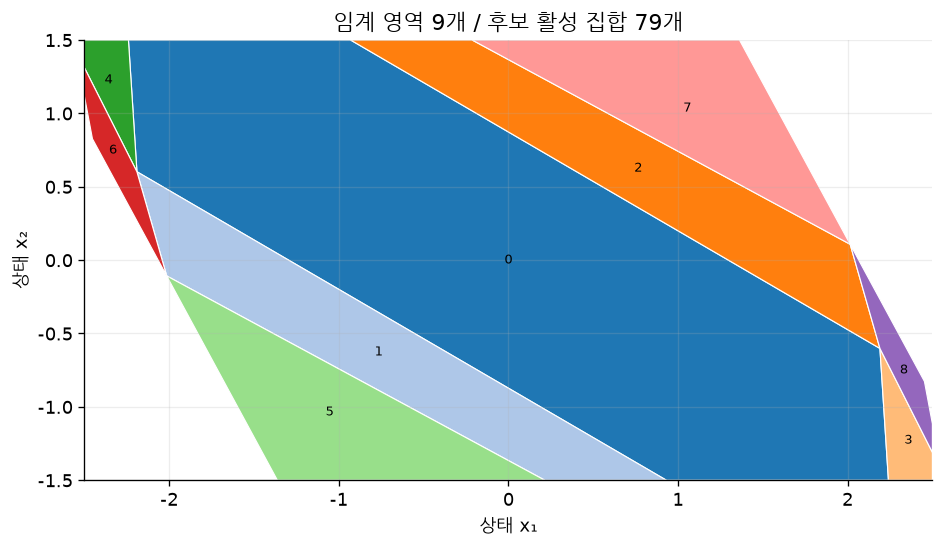

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.7))
for i, r in enumerate(regions):
    ax.add_patch(
        Polygon(r["poly"], facecolor=plt.cm.tab20(i % 20), edgecolor="white", lw=0.7)
    )
    center = np.mean(r["poly"], axis=0)
    ax.text(*center, str(i), fontsize=8, ha="center", va="center")
ax.set(
    xlim=(-2.5, 2.5),
    ylim=(-1.5, 1.5),
    xlabel="상태 x₁",
    ylabel="상태 x₂",
    title=f"임계 영역 {len(regions)}개 / 후보 활성 집합 {candidates}개",
)
savefig(fig, "regions")


### 7.3.3 Optimality Condition for a Convex Program — 볼록 문제의 최적성 조건

**교재 인쇄 pp.459–462**

볼록 미분 가능 비용에서 최적점의 모든 실행 가능 방향으로의 방향 미분은 음수가 아니어야 합니다. 다면체에서는 음의 비용 기울기가 활성 제약의 바깥 법선들이 만드는 원뿔에 속한다는 조건으로 표현할 수 있습니다. 이는 비음수 승수와 정지 조건으로 이어집니다.

보충 기하 예제는 $[-1,1]^2$ 안에서 목표 $t=(1.4,0.4)$에 가장 가까운 점을 찾습니다. 최적점 $(1,0.4)$에서 음의 기울기는 오른쪽 활성 경계의 바깥 법선과 같습니다. 이 2차원 변수는 주 MPC의 상태가 아닌 별도 최적화 변수입니다.

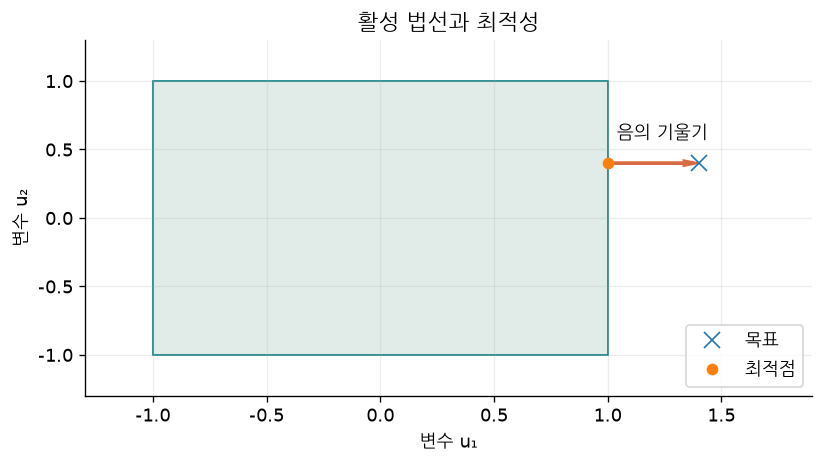

In [5]:
target = np.array([1.4, 0.4])
optimum = np.clip(target, -1, 1)
grad = optimum - target
rng = np.random.default_rng(7)
feasible = rng.uniform(-1, 1, (1000, 2))
assert np.min((feasible - optimum) @ grad) >= -1e-12
record("기하 예제 정지 잔차", np.linalg.norm(grad + np.array([0.4, 0.0])), 1e-12)
fig, ax = plt.subplots(figsize=(7, 4))
ax.add_patch(
    Polygon(
        [[-1, -1], [1, -1], [1, 1], [-1, 1]], facecolor="#e1ece8", edgecolor="#087e82"
    )
)
ax.plot(*target, "x", ms=10, label="목표")
ax.plot(*optimum, "o", label="최적점")
ax.arrow(*optimum, *(-grad), width=0.015, length_includes_head=True, color="#d96b43")
ax.text(1.04, 0.58, "음의 기울기", fontsize=11)
ax.set(
    xlim=(-1.3, 1.9),
    ylim=(-1.3, 1.3),
    xlabel="변수 u₁",
    ylabel="변수 u₂",
    title="활성 법선과 최적성",
)
ax.legend(loc="lower right")
savefig(fig, "normal_cone")


### 7.3.4 Solution of the Parametric Quadratic Program — 임계 영역과 아핀 해 계산

**교재 인쇄 pp.462–466**

독립 활성 행 $G_I$를 고정하고 KKT 선형 시스템을 풀어 $U=K_ix+k_i$, $\lambda_I=L_ix+l_i$를 얻습니다. 모든 원래 제약과 활성 승수의 비음수 조건을 대입하면 임계 영역의 반평면 표현을 얻습니다. 내부가 없는 후보는 영역 목록에서 제외합니다.

아래 검증은 원래 상태·입력 변수와 동역학을 유지한 온라인 QP를 따로 풉니다. 파라미터 상자의 격자·고정 난수점과 영역 꼭짓점에서 실행 가능 여부와 최적 입력·비용을 비교합니다. 이 방법은 상태 제거 행렬의 오류도 찾는 데 도움이 됩니다. 유한 표본 검증 자체가 일반적 정리의 증명은 아닙니다.

$$
\begin{bmatrix}H&G_I^T\\G_I&0\end{bmatrix}\begin{bmatrix}U\\\lambda_I\end{bmatrix}=\begin{bmatrix}-Fx\\W_Ix+b_I\end{bmatrix}
$$

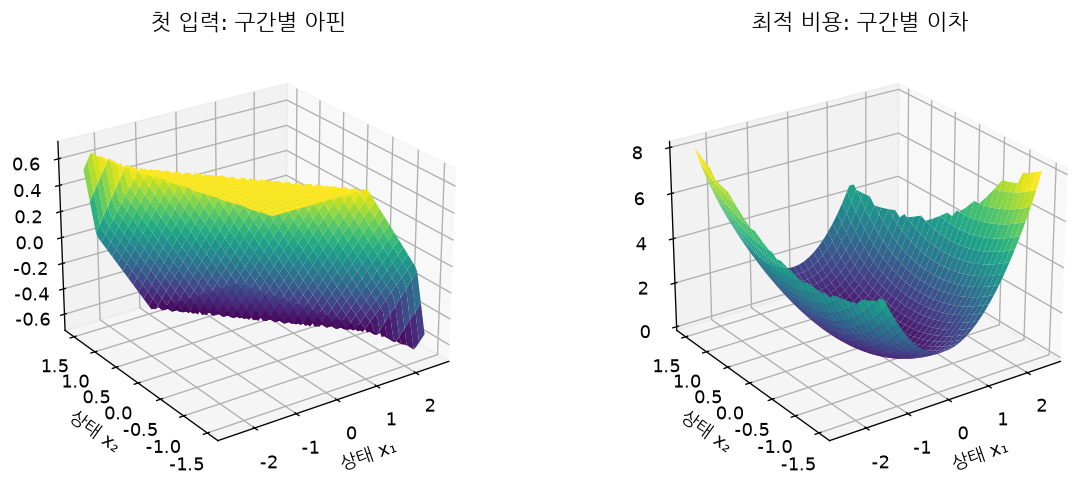

In [6]:
samples = np.vstack(
    [
        np.array(
            [
                (x, y)
                for x in np.linspace(-2.5, 2.5, 15)
                for y in np.linspace(-1.5, 1.5, 11)
            ]
        ),
        rng.uniform(-xbound, xbound, (80, 2)),
        *[r["poly"] for r in regions],
    ]
)
errors = []
cost_errors = []
mismatches = 0
primal = []
stationarity = []
for x in samples:
    rs = matching(x)
    result = online(x)
    mismatches += bool(rs) != (result is not None)
    if rs and result is not None:
        ue = explicit(x)
        errors.append(np.max(abs(ue - result[0])))
        cost_errors.append(abs(value(x, ue) - result[1]))
        r = rs[0]
        lam = r["L"] @ x + r["ell"]
        ids = list(r["active"])
        primal.append(max(0.0, np.max(G @ ue - W @ x - b)))
        stationarity.append(np.max(abs(H @ ue + F @ x + G[ids].T @ lam)))
record("실행 가능 판정 불일치 수", mismatches, 0.5)
record("전체 입력 열 QP 비교 최대 오차", max(errors), 5e-5)
record("최적 비용 QP 비교 최대 오차", max(cost_errors), 2e-7)
record("원래 부등식 위반", max(primal), 1e-7)
record("KKT 정지 잔차", max(stationarity), 1e-9)
CHECKS["검증 상태 수"] = len(samples)
grid1 = np.linspace(-2.5, 2.5, 81)
grid2 = np.linspace(-1.5, 1.5, 61)
gx, gy = np.meshgrid(grid1, grid2)
gu = np.full_like(gx, np.nan)
gv = gu.copy()
for index in np.ndindex(gx.shape):
    x = np.array([gx[index], gy[index]])
    if matching(x):
        gu[index] = explicit(x)[0]
        gv[index] = value(x)
fig = plt.figure(figsize=(11, 4.2))
for j, (z, title) in enumerate(
    [(gu, "첫 입력: 구간별 아핀"), (gv, "최적 비용: 구간별 이차")]
):
    ax = fig.add_subplot(1, 2, j + 1, projection="3d")
    ax.plot_surface(gx, gy, z, cmap="viridis", linewidth=0)
    ax.set(xlabel="상태 x₁", ylabel="상태 x₂", title=title)
    ax.view_init(25, -125)
savefig(fig, "policy_value")


#### 원본 예제 7.11: 상태에 따라 움직이는 세 입력 하한

**원본 인쇄 pp.464–465 및 §7.2**의 문제를 그대로 사용합니다.
$$V(x,u)=\frac12x^2-xu+u^2,\qquad u\ge1,\quad u\ge2-\frac{x}{2},\quad u\ge2-x.$$
제약 없는 해는 $x/2$입니다. 따라서 최적 입력은 이 값과 세 하한의 최댓값입니다.
$$u^*(x)=\begin{cases}2-x&x\le0,\\2-x/2&0\le x\le2,\\x/2&x\ge2.\end{cases}$$
원본에서 $x=1$의 활성 제약은 두 번째이고 해당 임계 영역은 $[0,2]$입니다. 아래는 원본에서 구한 영역을 전체 실수 축으로 이어 쓴 결과이며, 온라인 QP와 비교합니다. 하한 1이 단독으로 최적 입력을 결정하는 내부 영역은 없습니다. 경계 $x=2$에서는 제약이 등호여도 승수가 0일 수 있습니다.

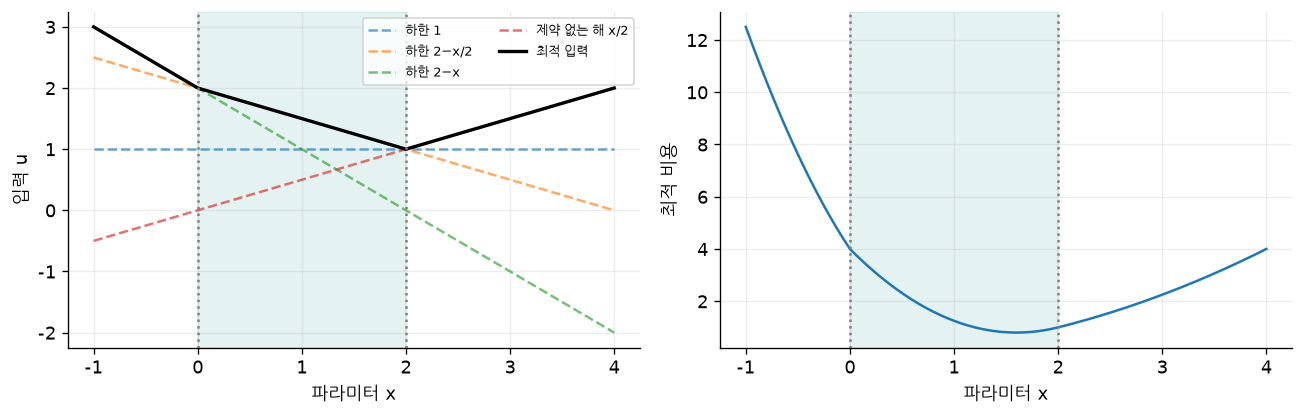

In [7]:
def textbook11(x):
    x = np.asarray(x, dtype=float)
    return np.maximum.reduce([x / 2, np.ones_like(x), 2 - x / 2, 2 - x])


def cost11(x):
    u = textbook11(x)
    return 0.5 * x * x - x * u + u * u


z11 = np.linspace(-1, 4, 151)
u11 = textbook11(z11)
v11 = cost11(z11)
tx = cp.Parameter()
tu = cp.Variable()
p11 = cp.Problem(
    cp.Minimize(0.5 * cp.square(tx) - tx * tu + cp.square(tu)),
    [tu >= 1, tu >= 2 - tx / 2, tu >= 2 - tx],
)
e11 = []
for xx11 in np.r_[np.linspace(-1, 4, 26), 0.0, 1.0, 2.0]:
    tx.value = xx11
    p11.solve(solver=cp.CLARABEL, tol_gap_abs=1e-11, tol_gap_rel=1e-11, tol_feas=1e-11)
    assert p11.status == cp.OPTIMAL
    e11.append(abs(tu.value - textbook11(xx11)))
assert max(e11) < 2e-5 and textbook11(1) == 1.5
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
for line, label in [
    (np.ones_like(z11), "하한 1"),
    (2 - z11 / 2, "하한 2−x/2"),
    (2 - z11, "하한 2−x"),
    (z11 / 2, "제약 없는 해 x/2"),
]:
    axs[0].plot(z11, line, ls="--", alpha=0.65, label=label)
axs[0].plot(z11, u11, "k", lw=2, label="최적 입력")
axs[0].set(xlabel="파라미터 x", ylabel="입력 u")
axs[0].legend(fontsize=8, ncol=2)
axs[1].plot(z11, v11)
axs[1].set(xlabel="파라미터 x", ylabel="최적 비용")
for ax in axs:
    ax.axvspan(0, 2, alpha=0.1, color="teal")
    ax.axvline(0, color="gray", ls=":")
    ax.axvline(2, color="gray", ls=":")
record("원본 7.11 QP 입력 비교 오차", max(e11), 2e-5)
record("원본 7.11 x=1의 최적 입력", float(textbook11(1)))
savefig(fig, "textbook11")


#### 원본 예제 7.12: 전체 입력 열은 다섯 영역, 첫 입력은 세 식

**원본 인쇄 pp.465–466, 예제 2.5와 연결**합니다. 결정 변수는 길이 2의 입력 열입니다.
$$V(x,U)=\frac32x^2+[2x,x]U+\frac12U^T\begin{bmatrix}3&1\\1&2\end{bmatrix}U,\qquad |U_i|\le1.$$
양의 상태에서 $x\le5/3$이면 $U=(-3x/5,-x/5)$, $5/3\le x\le3$이면 $U=(-1,(1-x)/2)$, $x\ge3$이면 $U=(-1,-1)$입니다. 음의 상태는 대칭입니다. 원본의 $x=2$에서는 $U=(-1,-1/2)$, 해당 영역은 $[5/3,3]$입니다.

전체 계획은 $-3,-5/3,5/3,3$에서 식이 바뀌지만 **첫 입력은 $u=\operatorname{clip}(-3x/5,-1,1)$** 하나로 표현할 수 있습니다. 뒤 입력의 활성 제약 변화가 현재 적용할 입력 식을 항상 바꾸는 것은 아닙니다.

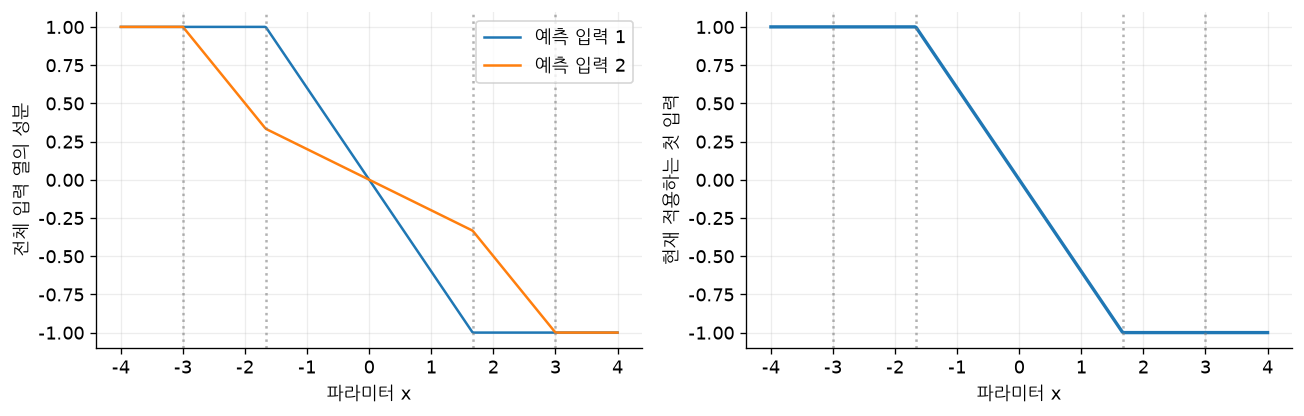

In [8]:
h12 = np.array([[3.0, 1.0], [1.0, 2.0]])


def textbook12(x):
    ax = abs(x)
    sg = np.sign(x)
    if ax <= 5 / 3:
        return np.array([-0.6 * x, -0.2 * x])
    if ax <= 3:
        return np.array([-sg, sg * (1 - ax) / 2])
    return np.array([-sg, -sg])


t12 = cp.Parameter()
u12var = cp.Variable(2)
p12 = cp.Problem(
    cp.Minimize(
        1.5 * cp.square(t12)
        + t12 * (2 * u12var[0] + u12var[1])
        + 0.5 * cp.quad_form(u12var, h12)
    ),
    [cp.abs(u12var) <= 1],
)
e12 = []
v12err = []
for xx12 in np.r_[np.linspace(-4, 4, 41), -3.0, -5 / 3, 5 / 3, 2.0, 3.0]:
    t12.value = xx12
    p12.solve(solver=cp.CLARABEL, tol_gap_abs=1e-11, tol_gap_rel=1e-11, tol_feas=1e-11)
    assert p12.status == cp.OPTIMAL
    exact12 = textbook12(xx12)
    e12.append(np.max(abs(exact12 - u12var.value)))
    v12err.append(
        abs(
            1.5 * xx12**2
            + xx12 * np.array([2.0, 1.0]) @ exact12
            + 0.5 * exact12 @ h12 @ exact12
            - p12.value
        )
    )
assert max(e12) < 2e-5 and np.allclose(textbook12(2), [-1, -0.5])
z12 = np.linspace(-4, 4, 401)
plans12 = np.array([textbook12(x) for x in z12])
assert np.max(abs(plans12[:, 0] - np.clip(-0.6 * z12, -1, 1))) < 1e-12
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
for j in range(2):
    axs[0].plot(z12, plans12[:, j], label=f"예측 입력 {j+1}")
axs[0].legend()
axs[0].set(xlabel="파라미터 x", ylabel="전체 입력 열의 성분")
axs[1].plot(z12, plans12[:, 0], lw=2)
axs[1].set(xlabel="파라미터 x", ylabel="현재 적용하는 첫 입력")
for ax in axs:
    for brk in [-3, -5 / 3, 5 / 3, 3]:
        ax.axvline(brk, color="gray", ls=":", alpha=0.6)
record("원본 7.12 전체 입력 QP 비교 오차", max(e12), 2e-5)
record("원본 7.12 최적 비용 비교 오차", max(v12err), 1e-8)
savefig(fig, "textbook12")


### 7.3.5 Continuity of V⁰(·) and u⁰(·) — 입력과 비용의 연속성

**교재 인쇄 pp.466–467**

서로 만나는 임계 영역의 아핀 해는 공유 경계에서 같은 최적해를 나타내야 합니다. 유일성이 이 일치를 뒷받침합니다. 유한한 영역들의 연속 함수가 경계에서 일치하므로 전체 해와 비용의 연속성을 연결할 수 있습니다. 연속성은 모든 지점에서 같은 미분값을 가진다는 뜻은 아닙니다.

모든 다각형 꼭짓점에서 해당하는 영역들의 입력·비용을 비교합니다. 이 2차원 분할에서는 공유 선분의 끝점도 포함됩니다. 추가로 실제로 여러 영역이 만나는 표본이 있는지 확인합니다. 스칼라 예제는 연속인 입력의 기울기가 포화 경계에서 바뀌는 모습을 보여 줍니다.

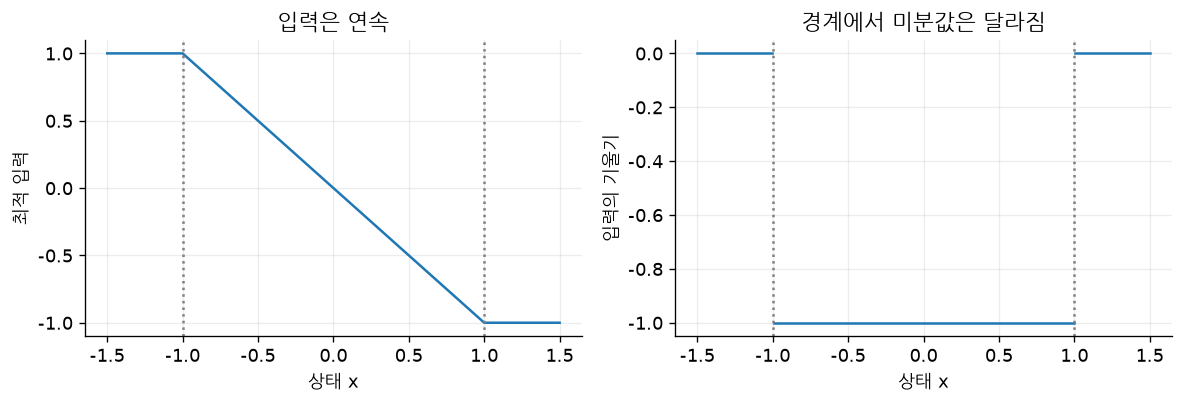

In [9]:
boundary_count = 0
bu = []
bv = []
for r in regions:
    for x in r["poly"]:
        rs = matching(x)
        if len(rs) > 1:
            boundary_count += 1
            us = [q["K"] @ x + q["k"] for q in rs]
            vs = [0.5 * x @ q["Pi"] @ x + q["qi"] @ x + q["ri"] for q in rs]
            bu.append(np.max(np.ptp(np.array(us), axis=0)))
            bv.append(np.ptp(vs))
assert boundary_count > 0
record("공유 경계 입력 불일치", max(bu), 1e-7)
record("공유 경계 비용 불일치", max(bv), 1e-7)
CHECKS["공유 경계 검사 수"] = boundary_count
fig, axs = plt.subplots(1, 2, figsize=(10, 3.5))
z = np.linspace(-1.5, 1.5, 601)
axs[0].plot(z, -np.clip(z, -1, 1))
slope = np.where(abs(z) < 1, -1.0, 0.0)
slope[np.isclose(abs(z), 1)] = np.nan
axs[1].plot(z, slope)
for ax in axs:
    ax.set_xlabel("상태 x")
    ax.axvline(-1, color="gray", ls=":")
    ax.axvline(1, color="gray", ls=":")
axs[0].set(ylabel="최적 입력", title="입력은 연속")
axs[1].set(ylabel="입력의 기울기", title="경계에서 미분값은 달라짐")
savefig(fig, "continuity")


#### 보충 해석: 유일한 입력이어도 비용의 미분은 불연속일 수 있다

원본 예제 7.11의 $x=0$에서 두 입력 하한 $2-x/2$와 $2-x$가 동시에 활성화됩니다. 활성 제약의 입력 법선은 둘 다 −1이라 종속입니다. 최적 입력은 유일한 2이지만 승수는 $\lambda_2+\lambda_3=4$, $\lambda_2,\lambda_3\ge0$으로 유일하지 않습니다.

최적 비용은 왼쪽에서 $\frac52x^2-6x+4$, 가운데에서 $\frac54x^2-4x+4$, 오른쪽에서 $x^2/4$입니다. 따라서 $x=0$의 **좌미분은 −6, 우미분은 −4**입니다. 비용의 연속성과 미분 가능성은 다른 성질입니다.

라그랑지안의 상태 미분은 $x-u-\lambda_2/2-\lambda_3$입니다. 최적 승수들을 대입하면 $x=0$의 부분기울기 구간 $[-6,-4]$를 얻습니다. 이 계산은 원본 수치 문제를 이용한 보충 민감도 분석입니다. 종속 활성 행을 모두 넣은 KKT 행렬이 특이해도 원래 QP의 입력 해가 비유일하다는 뜻은 아닙니다.

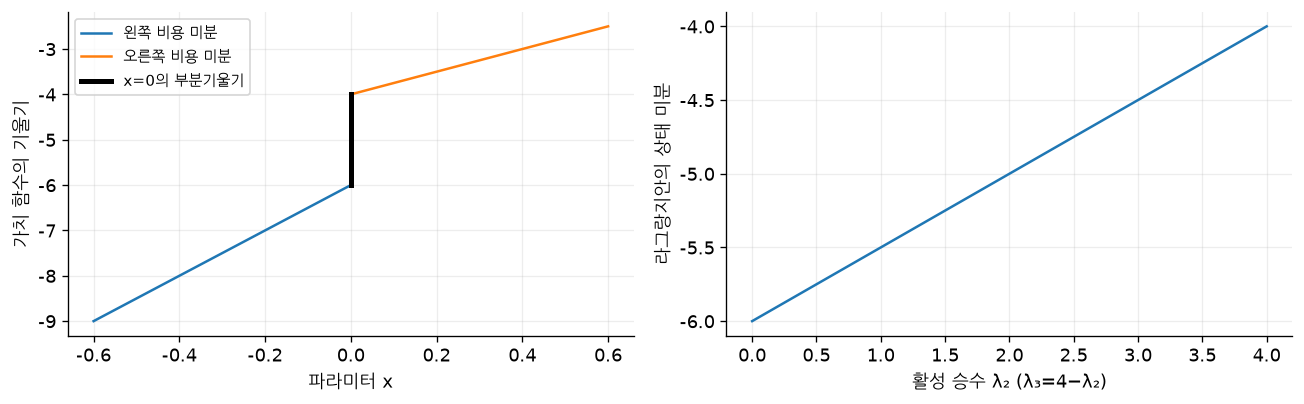

In [10]:
lam2 = np.linspace(0, 4, 101)
lam3 = 4 - lam2
subgrad = -2 - 0.5 * lam2 - lam3
assert np.max(abs(-0 + 2 * 2 - lam2 - lam3)) < 1e-12
singular = np.array([[2.0, -1.0, -1.0], [-1.0, 0.0, 0.0], [-1.0, 0.0, 0.0]])
assert np.linalg.matrix_rank(singular) == 2
h7 = 1e-6
left = (cost11(0) - cost11(-h7)) / h7
right = (cost11(h7) - cost11(0)) / h7
assert abs(left + 6) < 1e-5 and abs(right + 4) < 1e-5
fig, axs = plt.subplots(1, 2, figsize=(11, 3.5))
negative = np.linspace(-0.6, -1e-5, 150)
positive = np.linspace(1e-5, 0.6, 150)
axs[0].plot(negative, 5 * negative - 6, label="왼쪽 비용 미분")
axs[0].plot(positive, 2.5 * positive - 4, label="오른쪽 비용 미분")
axs[0].plot([0, 0], [-6, -4], "k-", lw=3, label="x=0의 부분기울기")
axs[0].set(xlabel="파라미터 x", ylabel="가치 함수의 기울기")
axs[0].legend(fontsize=9)
axs[1].plot(lam2, subgrad)
axs[1].set(xlabel="활성 승수 λ₂ (λ₃=4−λ₂)", ylabel="라그랑지안의 상태 미분")
record("원본 7.11 좌미분 검증 오차", abs(left + 6), 1e-5)
record("원본 7.11 우미분 검증 오차", abs(right + 4), 1e-5)
record("종속 활성 KKT 행렬 계수", np.linalg.matrix_rank(singular))
savefig(fig, "degenerate_sensitivity")


## 7.4 Constrained Linear Quadratic Control — 제약 선형 이차 제어

**교재 인쇄 pp.467–469**

선형 예측 모델의 상태를 제거하면 앞 절의 파라미터 QP를 얻습니다. 전체 입력 열을 미리 구하더라도 MPC는 현재 상태에서 첫 입력만 적용하고 다음 상태로 다시 영역을 찾습니다.

주 실습의 종단 상자는 영 입력에서 불변이고 $A^TPA-P=-Q$입니다. 최적 입력 열의 뒤에 0을 붙이는 이동 후보가 다음 시간에도 실행 가능하므로 최적 비용은 단계 비용 이상 감소합니다. 이 보장은 이 모델의 종단 조건에 근거하며 임의의 명시적 제어법칙에 자동으로 생기지 않습니다. 외란이 없는 폐루프를 비교합니다.

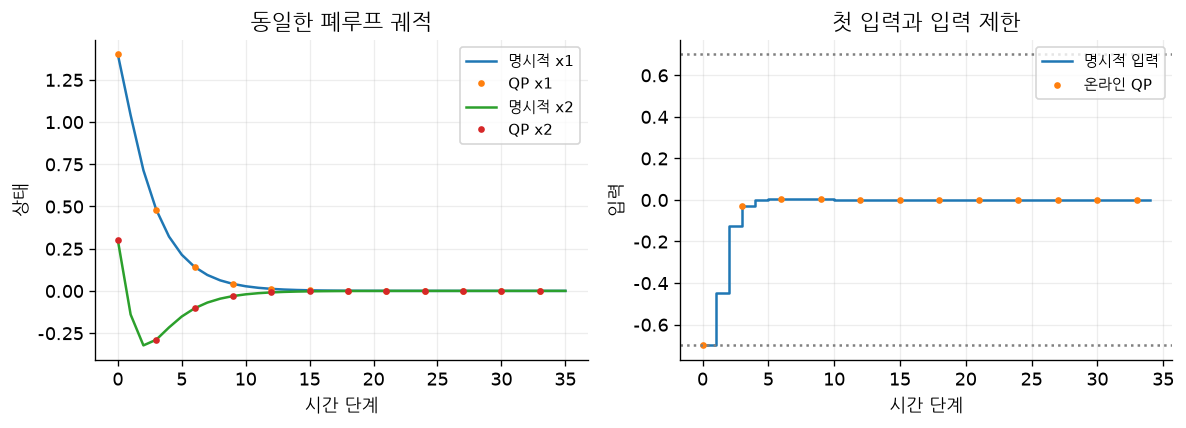

In [11]:
xe = np.array([1.4, 0.3])
xo = xe.copy()
xs = [xe.copy()]
xso = [xo.copy()]
uehist = []
uohist = []
decrease = []
for t in range(35):
    U = explicit(xe)
    res = online(xo)
    assert res is not None
    un = res[0][0]
    xn = A @ xe + B[:, 0] * U[0]
    decrease.append(value(xn) - value(xe) + 0.5 * (xe @ Q @ xe + R * U[0] ** 2))
    shifted = np.array([U[1], 0.0])
    assert np.max(G @ shifted - W @ xn - b) < 1e-8
    uehist.append(U[0])
    uohist.append(un)
    xe = xn
    xo = A @ xo + B[:, 0] * un
    xs.append(xe.copy())
    xso.append(xo.copy())
xs = np.array(xs)
xso = np.array(xso)
record("폐루프 상태 비교 오차", np.max(abs(xs - xso)), 1e-5)
record("폐루프 입력 비교 오차", np.max(abs(np.array(uehist) - uohist)), 1e-5)
record("단계 비용을 더한 비용 증가", max(0.0, max(decrease)), 1e-8)
record("폐루프 입력 제한 위반", max(0.0, max(abs(np.array(uehist))) - umax), 1e-8)
record("폐루프 최종 상태 노름", np.linalg.norm(xs[-1]), 1e-3)
fig, axs = plt.subplots(1, 2, figsize=(10, 3.7))
for j in range(2):
    axs[0].plot(xs[:, j], label=f"명시적 x{j+1}")
    axs[0].plot(np.arange(0, 36, 3), xso[::3, j], "o", ms=3, label=f"QP x{j+1}")
axs[1].step(range(35), uehist, where="post", label="명시적 입력")
axs[1].plot(np.arange(0, 35, 3), np.array(uohist)[::3], "o", ms=3, label="온라인 QP")
axs[1].axhline(umax, color="gray", ls=":")
axs[1].axhline(-umax, color="gray", ls=":")
for ax in axs:
    ax.set_xlabel("시간 단계")
    ax.legend(fontsize=9)
axs[0].set(ylabel="상태", title="동일한 폐루프 궤적")
axs[1].set(ylabel="입력", title="첫 입력과 입력 제한")
savefig(fig, "closed_loop")


## 7.5 Parametric Piecewise Quadratic Programming — 파라미터 구간별 이차계획법

**교재 인쇄 pp.469–475**

DP에서 이전 가치 함수가 구간별 이차 함수이면 한 단계 비용과의 합도 구간별 이차 함수가 됩니다. 각 조각 안의 최적 후보를 구하고 실행 가능 영역을 반영한 뒤 전체 최솟값을 선택해야 합니다. 조각 경계에서는 미분이 하나로 정해지지 않을 수 있어 단일 조각의 내부 최적성만으로 전체 문제를 판단하면 안 됩니다.

**별도 스칼라 보충 모델:** $x^+=0.9x+u$, $|x|\le2$, $|u|\le0.4$, 단계 비용 $(x^2+0.2u^2)/2$, 종단 집합 $|x|\le0.6$, 종단 비용 $Px^2/2$, $P=1/(1-0.9^2)$입니다.

아래 코드는 각 이전 이차 조각에서 자유 최적 입력, 입력 상·하한, 다음 상태 조각의 상·하한 후보를 구합니다. 후보의 실행 가능 구간과 경계 미분 부호를 검사하고, 이차 함수 교점에서 구간을 나누어 하단 포락선을 만듭니다. 부동소수점 허용오차를 쓰는 교육용 스칼라 구현이며 일반 다차원 PWQ 라이브러리가 아닙니다.

예측 구간, 이차 조각 수, 실행 가능 구간
0 1 (-0.6, 0.6)
1 3 (-1.1111111111111112, 1.1111111111111112)
2 5 (-1.6790123456790123, 1.6790123456790123)
3 7 (-2.0, 2.0)
4 7 (-2.0, 2.0)
5 7 (-2.0, 2.0)


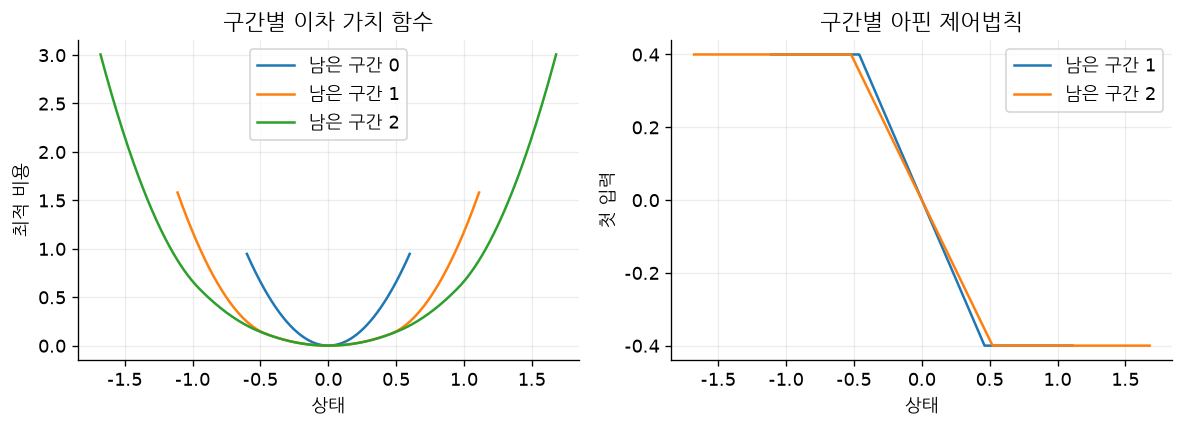

In [12]:
# 구간별 이차 함수를 정확한 후보식과 교점으로 분할한다. 격자는 시각화에만 사용.
a = 0.9
ru = 0.2
lim = 0.4
terminal = 0.6
pf = 1 / (1 - a * a)
# 각 조각: l,r,P,q,c,k,d (값=Px²/2+qx+c, 첫 입력=kx+d)
Vpieces = [[dict(l=-terminal, r=terminal, P=pf, q=0.0, c=0.0, k=0.0, d=0.0)]]


def restrict(lo, hi, alpha, beta):
    # alpha*x <= beta
    if abs(alpha) < 1e-12:
        return (lo, hi) if beta >= -1e-10 else (1.0, -1.0)
    if alpha > 0:
        hi = min(hi, beta / alpha)
    else:
        lo = max(lo, beta / alpha)
    return lo, hi


def bellman(prev):
    if not prev:
        raise ValueError("이전 가치 함수 조각이 비어 있습니다.")
    cand = []
    for p in prev:
        pp, q, c = p["P"], p["q"], p["c"]
        choices = [
            (-a * pp / (ru + pp), -q / (ru + pp), 0),
            (0.0, -lim, -1),
            (-a, p["l"], -1),
            (0.0, lim, 1),
            (-a, p["r"], 1),
        ]
        for k, d, kind in choices:
            lo, hi = -2.0, 2.0
            inequalities = [
                (k, lim - d),
                (-k, lim + d),
                (a + k, p["r"] - d),
                (-a - k, d - p["l"]),
            ]
            # 구간의 아래 끝에서는 미분 >=0, 위 끝에서는 미분 <=0.
            if kind:
                inequalities.append(
                    (kind * ((ru + pp) * k + pp * a), -kind * ((ru + pp) * d + q))
                )
            for al, be in inequalities:
                lo, hi = restrict(lo, hi, al, be)
            if hi - lo > 1e-9:
                cand.append(
                    dict(
                        l=lo,
                        r=hi,
                        P=1 + ru * k * k + pp * (a + k) ** 2,
                        q=ru * k * d + pp * (a + k) * d + q * (a + k),
                        c=0.5 * (ru + pp) * d * d + q * d + c,
                        k=k,
                        d=d,
                    )
                )
    cuts = [v[key] for v in cand for key in ("l", "r")]
    for i, p in enumerate(cand):
        for q in cand[:i]:
            coeff = np.array(
                [0.5 * (p["P"] - q["P"]), p["q"] - q["q"], p["c"] - q["c"]]
            )
            coeff = np.trim_zeros(np.where(abs(coeff) < 1e-10, 0, coeff), "f")
            if len(coeff) > 1:
                for z in np.roots(coeff):
                    if abs(z.imag) < 1e-9 and max(p["l"], q["l"]) < z.real < min(
                        p["r"], q["r"]
                    ):
                        cuts.append(float(z.real))
    cuts = sorted(cuts)
    unique = [cuts[0]]
    for z in cuts[1:]:
        if z - unique[-1] > 1e-8:
            unique.append(z)
    result = []
    for lo, hi in zip(unique[:-1], unique[1:]):
        mid = (lo + hi) / 2
        valid = [p for p in cand if p["l"] - 1e-9 <= mid <= p["r"] + 1e-9]
        if not valid:
            continue
        best = min(
            valid, key=lambda p: 0.5 * p["P"] * mid**2 + p["q"] * mid + p["c"]
        ).copy()
        best.update(l=lo, r=hi)
        if (
            result
            and abs(result[-1]["r"] - lo) < 1e-7
            and max(
                abs(best[key] - result[-1][key]) for key in ("P", "q", "c", "k", "d")
            )
            < 1e-7
        ):
            result[-1]["r"] = hi
        else:
            result.append(best)
    return result


for horizon in range(1, 6):
    Vpieces.append(bellman(Vpieces[-1]))


def dp_eval(h, x):
    if (
        isinstance(h, bool)
        or not isinstance(h, (int, np.integer))
        or not 0 <= h < len(Vpieces)
    ):
        raise ValueError("계산된 DP 구간 번호를 지정하세요.")
    if np.ndim(x) != 0 or not np.isfinite(x):
        raise ValueError("DP 상태는 유한한 스칼라여야 합니다.")
    ps = [p for p in Vpieces[h] if p["l"] - 1e-8 <= x <= p["r"] + 1e-8]
    if not ps:
        raise ValueError("DP 실행 가능 구간 밖입니다.")
    p = ps[0]
    return p["k"] * x + p["d"], 0.5 * p["P"] * x * x + p["q"] * x + p["c"]


print("예측 구간, 이차 조각 수, 실행 가능 구간")
for h, ps in enumerate(Vpieces):
    print(h, len(ps), (ps[0]["l"], ps[-1]["r"]))
fig, axs = plt.subplots(1, 2, figsize=(10, 3.7))
for h in (0, 1, 2):
    ps = Vpieces[h]
    xx = np.linspace(ps[0]["l"], ps[-1]["r"], 501)
    vals = np.array([dp_eval(h, x) for x in xx])
    axs[0].plot(xx, vals[:, 1], label=f"남은 구간 {h}")
    if h:
        axs[1].plot(xx, vals[:, 0], label=f"남은 구간 {h}")
axs[0].set(xlabel="상태", ylabel="최적 비용", title="구간별 이차 가치 함수")
axs[1].set(xlabel="상태", ylabel="첫 입력", title="구간별 아핀 제어법칙")
for ax in axs:
    ax.legend()
savefig(fig, "dp_pwq")


## 7.6 DP Solution of the Constrained LQ Control Problem — 동적 계획법으로 제약 LQ 풀기

**교재 인쇄 pp.475–476**

DP는 전체 입력 열을 한꺼번에 최적화하는 대신 한 시점의 입력만을 결정 변수로 사용합니다. 대신 이전 단계의 영역 분할과 가치 함수를 유지해야 하므로 계산 문제가 사라지는 것은 아닙니다.

스칼라 실습에서 남은 구간 1–5의 아핀 입력·이차 비용을 원래 동역학을 가진 다단계 QP와 비교합니다. 각 구간의 내부와 경계, 전체 실행 가능 구간의 끝을 표본에 포함합니다. 영역 수와 실행 가능 구간을 함께 표시합니다. 특정 예제에서 관측한 영역 수를 일반적인 복잡도 법칙으로 해석하지 않습니다.

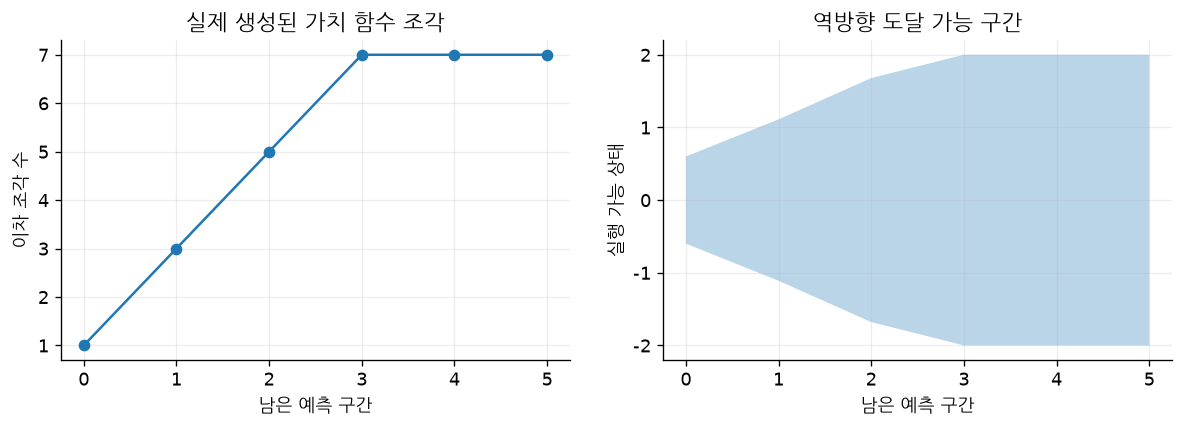

In [13]:
dperr = []
dpverr = []
dpboundary = []
for h in range(1, 6):
    ps = Vpieces[h]
    z = cp.Variable(h + 1)
    v = cp.Variable(h)
    param = cp.Parameter()
    co = [z[0] == param, cp.abs(z) <= 2, cp.abs(v) <= lim, cp.abs(z[-1]) <= terminal]
    co += [z[1:] == a * z[:-1] + v]
    pr = cp.Problem(
        cp.Minimize(
            0.5
            * (cp.sum_squares(z[:-1]) + ru * cp.sum_squares(v) + pf * cp.square(z[-1]))
        ),
        co,
    )
    test = np.unique(
        np.r_[
            np.linspace(ps[0]["l"], ps[-1]["r"], 21),
            [p["l"] for p in ps],
            [p["r"] for p in ps],
        ]
    )
    for x in test:
        param.value = x
        pr.solve(
            solver=cp.CLARABEL, tol_gap_abs=1e-10, tol_feas=1e-10, tol_gap_rel=1e-10
        )
        assert pr.status == cp.OPTIMAL
        du, dv = dp_eval(h, x)
        dperr.append(abs(du - v.value[0]))
        dpverr.append(abs(dv - pr.value))
    for left, right in zip(ps[:-1], ps[1:]):
        x = left["r"]
        assert abs(x - right["l"]) < 1e-7
        dpboundary += [
            abs(left["k"] * x + left["d"] - right["k"] * x - right["d"]),
            abs(
                0.5 * (left["P"] - right["P"]) * x * x
                + (left["q"] - right["q"]) * x
                + left["c"]
                - right["c"]
            ),
        ]
record("DP 입력 QP 비교 최대 오차", max(dperr), 5e-5)
record("DP 비용 QP 비교 최대 오차", max(dpverr), 2e-7)
record("DP 조각 경계 불일치", max(dpboundary), 1e-6)
fig, axs = plt.subplots(1, 2, figsize=(10, 3.7))
hh = np.arange(6)
axs[0].plot(hh, [len(p) for p in Vpieces], "o-")
axs[0].set(
    xlabel="남은 예측 구간", ylabel="이차 조각 수", title="실제 생성된 가치 함수 조각"
)
axs[1].fill_between(
    hh, [p[0]["l"] for p in Vpieces], [p[-1]["r"] for p in Vpieces], alpha=0.3
)
axs[1].set(
    xlabel="남은 예측 구간", ylabel="실행 가능 상태", title="역방향 도달 가능 구간"
)
savefig(fig, "dp_validation")


## 7.7 Parametric Linear Programming — 파라미터 선형계획법

**교재 인쇄 pp.476–481**

목적함수가 선형이면 최적 비용은 다면체 영역 위에서 구간별 아핀 구조를 갖습니다. 그러나 최적 입력은 한 점이 아닌 선분이나 면 전체일 수 있습니다. 최적해의 선택 규칙과 그 연속성을 별도로 다루어야 합니다.

이차 비용의 엄격 볼록성에서 얻은 유일성을 선형 비용에 그대로 옮길 수 없습니다. 아래에서는 비유일한 LP와 모든 실행 가능 파라미터에서 유일한 LP를 분리해 비교합니다.

### 7.7.1 Preliminaries — LP 준비와 비유일한 최적해

**교재 인쇄 pp.476–478**

선형 비용의 등고선이 실행 가능 다면체의 면과 평행하면 그 면의 모든 점이 최적일 수 있습니다. 선형계획법 해석에서 꼭짓점 최적해의 존재와 유일성은 같은 말이 아닙니다.

보충 문제는 $\min(u_1+u_2)$, $u_1+u_2\ge t$, $u_1,u_2\ge0$, $t\in[0,1]$입니다. 최적 비용은 $t$이고 최적해는 $(\alpha t,(1-\alpha)t)$, $0\le\alpha\le1$입니다. 수치 솔버가 한 끝점을 반환해도 나머지 최적해가 사라지지 않습니다.

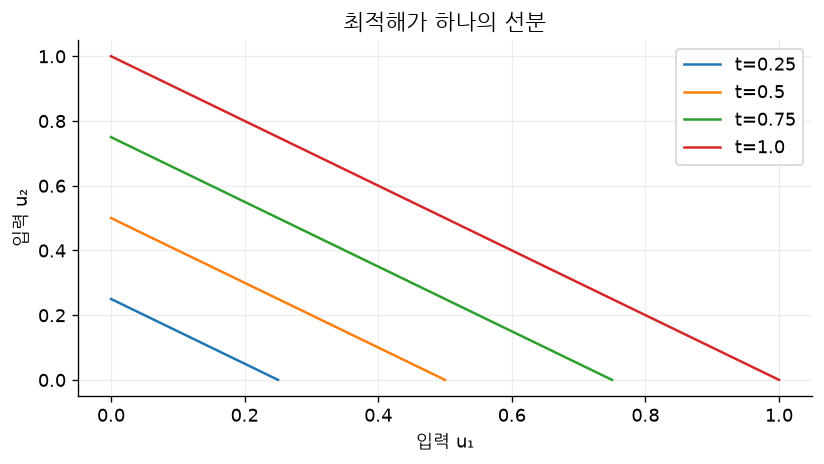

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
for t in (0.25, 0.5, 0.75, 1.0):
    sol = linprog(
        [1.0, 1.0],
        A_ub=[[-1.0, -1.0]],
        b_ub=[-t],
        bounds=[(0, None)] * 2,
        method="highs",
    )
    assert sol.success and abs(sol.fun - t) < 1e-10
    alpha = np.linspace(0, 1, 100)
    ax.plot(alpha * t, (1 - alpha) * t, label=f"t={t}")
    assert np.max(abs(alpha * t + (1 - alpha) * t - t)) < 1e-12
ax.set(xlabel="입력 u₁", ylabel="입력 u₂", title="최적해가 하나의 선분")
ax.legend()
savefig(fig, "lp_nonunique")
record("비유일 LP 마지막 비용 오차", abs(sol.fun - 1), 1e-10)


#### 보충 실습: 이차 정규화는 해의 선택과 목적함수를 바꾼다

앞의 LP에서 $t=1$로 고정하고 $J_\delta=(1+\delta)u_1+u_2$를 생각합니다. $\delta=0$이면 선분 전체가 최적이고, $\delta=0.1$이면 원래 LP의 유일한 최적해는 $(0,1)$입니다.

여기에 $\varepsilon\|u\|^2/2$를 더하면 엄격 볼록 QP가 됩니다. 최적점에서 $u_1+u_2=1$이고
$$u_1^\varepsilon=\operatorname{clip}\left(\frac12-\frac{\delta}{2\varepsilon},0,1\right),\qquad u_2^\varepsilon=1-u_1^\varepsilon.$$
$\delta=0$에서는 원래 최적 선분의 중앙을 선택합니다. 반면 $\delta=0.1$이고 $\varepsilon>0.1$이면 원래 LP의 최적점에서도 벗어나며 원래 선형 비용 손실은 $\delta u_1^\varepsilon$입니다. ‘작은 이차항’을 넣었다고 원래 문제와 항상 같은 해라고 해석하면 안 됩니다.

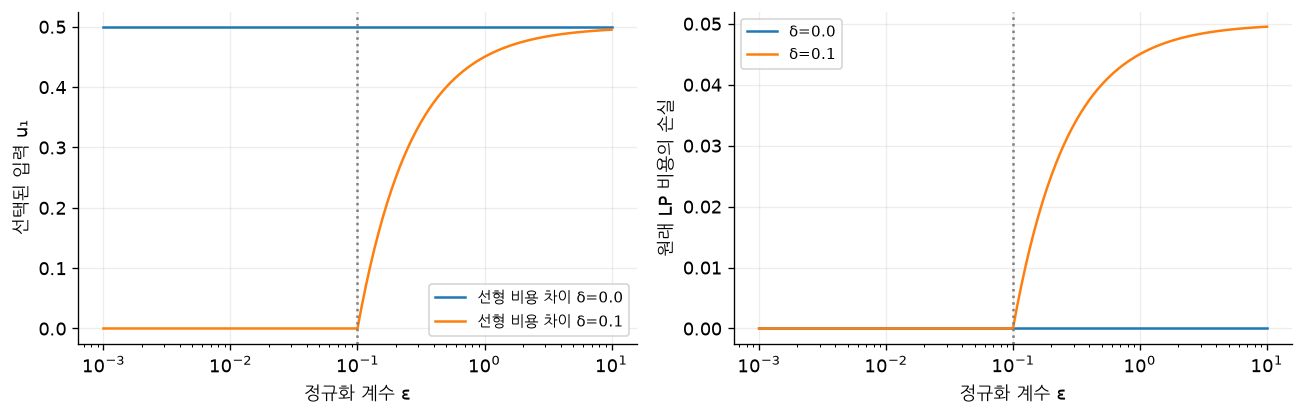

In [15]:
epsgrid = np.logspace(-3, 1, 121)
reg_error = []
rv = cp.Variable(2)
ep = cp.Parameter(nonneg=True)
delta7 = cp.Parameter(nonneg=True)
regprob = cp.Problem(
    cp.Minimize(cp.sum(rv) + delta7 * rv[0] + ep / 2 * cp.sum_squares(rv)),
    [rv >= 0, cp.sum(rv) >= 1],
)
fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
for delta in [0.0, 0.1]:
    first = np.clip(0.5 - delta / (2 * epsgrid), 0, 1)
    axs[0].semilogx(epsgrid, first, label=f"선형 비용 차이 δ={delta}")
    axs[1].semilogx(epsgrid, delta * first, label=f"δ={delta}")
    for eps in [0.001, 0.01, 0.1, 1.0, 10.0]:
        ep.value = eps
        delta7.value = delta
        regprob.solve(
            solver=cp.CLARABEL, tol_gap_abs=1e-12, tol_gap_rel=1e-12, tol_feas=1e-12
        )
        assert regprob.status == cp.OPTIMAL
        expected = np.clip(0.5 - delta / (2 * eps), 0, 1)
        reg_error.append(np.max(abs(rv.value - [expected, 1 - expected])))
axs[0].set(xlabel="정규화 계수 ε", ylabel="선택된 입력 u₁")
axs[1].set(xlabel="정규화 계수 ε", ylabel="원래 LP 비용의 손실")
for ax in axs:
    ax.legend(fontsize=9)
    ax.axvline(0.1, color="gray", ls=":")
record("정규화 QP 해 비교 최대 오차", max(reg_error), 2e-5)
record("정규화 ε=1 δ=0.1의 원래 LP 비용 손실", 0.1 * (0.5 - 0.1 / 2))
savefig(fig, "lp_regularization")


### 7.7.2 Minimizer u⁰(x) Is Unique for all x∈X — 모든 실행 가능 상태에서 유일한 LP 해

**교재 인쇄 pp.478–481**

교재의 이 절은 모든 실행 가능 파라미터에서 최적해가 유일하다는 가정 아래 해의 구조와 연속성을 다룹니다. 이 가정은 계산 결과를 본 뒤 생략할 수 있는 조건이 아닙니다.

보충 문제 $\min u$, $u\ge x$, $u\ge-x$, $u\ge0.3$, $u\le2$에서는 목적함수가 증가하므로 가장 작은 허용 입력이 유일한 최적해입니다. $|x|\le2$에서 $u^*(x)=\max(|x|,0.3)$이며 이 범위 밖은 실행 불가능합니다. 최적 비용도 같은 구간별 아핀 함수입니다.

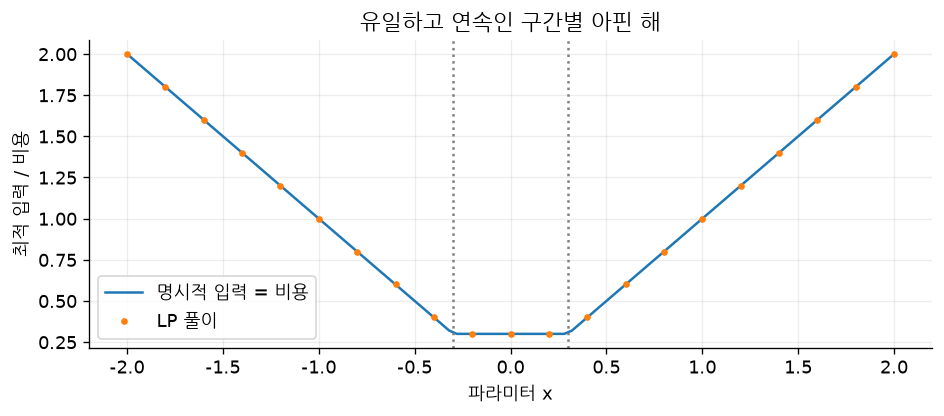

In [16]:
z = np.linspace(-2, 2, 101)
lpvalues = []
for x in z:
    sol = linprog(
        [1.0],
        A_ub=[[-1.0], [-1.0], [-1.0], [1.0]],
        b_ub=[-x, x, -0.3, 2.0],
        bounds=[(None, None)],
        method="highs",
    )
    assert sol.success
    lpvalues.append(sol.x[0])
record(
    "유일 LP 아핀 해 비교 오차",
    np.max(abs(np.array(lpvalues) - np.maximum(abs(z), 0.3))),
    1e-10,
)
for x in (-2.1, 2.1):
    sol = linprog(
        [1.0],
        A_ub=[[-1.0], [-1.0], [-1.0], [1.0]],
        b_ub=[-x, x, -0.3, 2.0],
        bounds=[(None, None)],
        method="highs",
    )
    assert sol.status == 2
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(z, np.maximum(abs(z), 0.3), label="명시적 입력 = 비용")
ax.plot(z[::5], np.array(lpvalues)[::5], "o", ms=3, label="LP 풀이")
ax.axvline(-0.3, color="gray", ls=":")
ax.axvline(0.3, color="gray", ls=":")
ax.set(
    xlabel="파라미터 x",
    ylabel="최적 입력 / 비용",
    title="유일하고 연속인 구간별 아핀 해",
)
ax.legend()
savefig(fig, "lp_unique")


## 7.8 Constrained Linear Control — 선형·노름 비용의 제약 제어

**교재 인쇄 pp.481–482**

선형 모델의 예측 상태를 입력 열로 표현하면 선형 비용의 제약 제어는 파라미터 LP가 됩니다. 1-노름과 무한대-노름 비용도 보조 변수를 도입해 LP로 바꿀 수 있습니다. 절댓값 제약 $t\ge z$, $t\ge-z$와 양의 비용 가중치를 사용하면 최적점에서 $t=|z|$입니다.

별도 1단계 보충 모델은 $x^+=0.9x+u$, $|u|\le0.6$, $|x|\le2$, $|x^+|\le2/3$이며 비용은 $|x|+0.4|u|+2|x^+|$입니다. 해는 $u=\mathrm{clip}(-0.9x,-0.6,0.6)$이고 실행 가능 구간은 $|x|\le(2/3+0.6)/0.9$입니다. 종단 입력 $-0.9x$는 종단 집합 안에서 허용되고 상태를 0으로 보내며, 종단 비용 $2|x|$는 단계 비용 $1.36|x|$보다 큽니다.

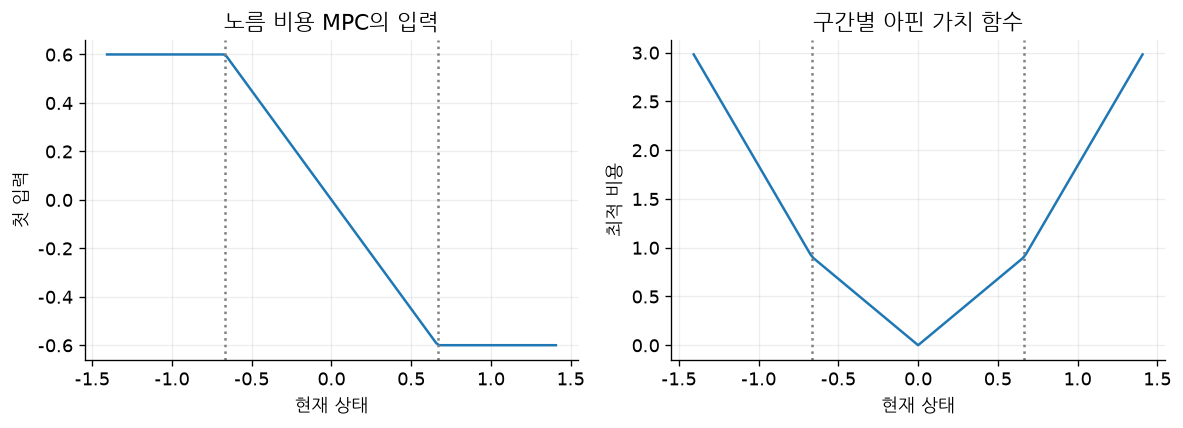

In [17]:
def norm_lp(x):
    # 변수 [u, t_u, t_next]. linprog 기본 비음수 입력 제약을 쓰지 않도록 bounds 명시.
    GG = np.array(
        [[1, -1, 0], [-1, -1, 0], [1, 0, -1], [-1, 0, -1], [1, 0, 0], [-1, 0, 0]]
    )
    bb = np.array([0, 0, -0.9 * x, 0.9 * x, 2 / 3 - 0.9 * x, 2 / 3 + 0.9 * x])
    sol = linprog(
        [0, 0.4, 2],
        A_ub=GG,
        b_ub=bb,
        bounds=[(-0.6, 0.6), (0, None), (0, None)],
        method="highs",
    )
    return sol


reach = (2 / 3 + 0.6) / 0.9
z = np.linspace(-reach, reach, 151)
nu = []
nv = []
for x in z:
    sol = norm_lp(x)
    assert sol.success
    nu.append(sol.x[0])
    nv.append(abs(x) + sol.fun)
expected = np.clip(-0.9 * z, -0.6, 0.6)
expected_v = abs(z) + 0.4 * abs(expected) + 2 * abs(0.9 * z + expected)
record("노름 MPC 입력 비교 오차", np.max(abs(np.array(nu) - expected)), 1e-10)
record("노름 MPC 비용 비교 오차", np.max(abs(np.array(nv) - expected_v)), 1e-10)
assert norm_lp(reach + 0.01).status == 2 and norm_lp(-reach - 0.01).status == 2
fig, axs = plt.subplots(1, 2, figsize=(10, 3.7))
axs[0].plot(z, nu)
axs[1].plot(z, nv)
for ax in axs:
    ax.set_xlabel("현재 상태")
    ax.axvline(-2 / 3, color="gray", ls=":")
    ax.axvline(2 / 3, color="gray", ls=":")
axs[0].set(ylabel="첫 입력", title="노름 비용 MPC의 입력")
axs[1].set(ylabel="최적 비용", title="구간별 아핀 가치 함수")
savefig(fig, "norm_mpc")


## 7.9 Computation — 계산과 구현

**교재 인쇄 pp.482–483**

영역 수는 상태 차원만으로 예측할 수 없습니다. 제약 수, 예측 구간, 퇴화, 영역 표현과 탐색 방법을 함께 보아야 합니다. 이 노트북의 활성 집합 전체 열거는 작은 문제의 구조를 드러내는 교육용 방법입니다.

실습의 2상태·1입력 구성에서 예측 구간 $N$에 대해 입력·예측 상태 제약을 합쳐 $6N$개라고 세면, 크기 $0$부터 $N$인 활성 집합 후보 수의 상한은 아래 합입니다. 실제 비어 있지 않은 영역 수는 이 수와 다릅니다. 경계에서는 허용오차와 일관된 선택 규칙을 쓰고, 영역 밖에서는 오류를 반환합니다. 배포용 구현은 수치 오차, 데이터 검증, 실패 대응을 별도로 설계해야 합니다.

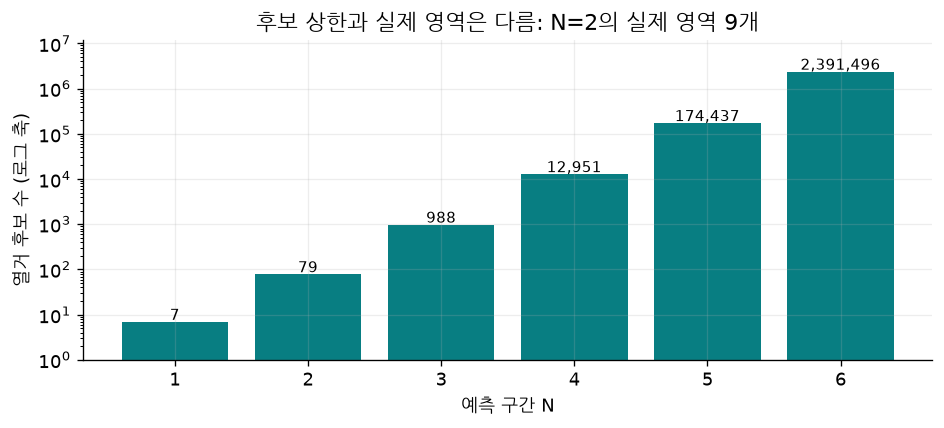

In [18]:
from math import comb

hh = np.arange(1, 7)
bounds = [sum(comb(6 * int(h), j) for j in range(int(h) + 1)) for h in hh]
assert bounds[1] == candidates
try:
    explicit(np.array([3.0, 0.0]))
except ValueError:
    pass
else:
    raise AssertionError("영역 밖 상태를 거부하지 않았습니다.")
record("실제 임계 영역 수", len(regions))
record("열거 활성 후보 수", candidates)
fig, ax = plt.subplots(figsize=(8, 3.7))
ax.bar(hh, bounds, color="#087e82")
ax.set_yscale("log")
ax.set(
    xlabel="예측 구간 N",
    ylabel="열거 후보 수 (로그 축)",
    title=f"후보 상한과 실제 영역은 다름: N=2의 실제 영역 {len(regions)}개",
)
for h, v in zip(hh, bounds):
    ax.text(h, v * 1.1, f"{v:,}", ha="center", fontsize=9)
ax.set_ylim(1, max(bounds) * 5)
savefig(fig, "complexity")


#### 보충 실습: 영역을 유지하면서 첫 입력 식을 재사용하기

§7.3.2의 구분을 실제 2차원 분할에 적용합니다. 전체 입력 열의 임계 영역 9개는 그대로 저장하되, 첫 입력의 계수 $(K_i[0,:],k_i[0])$가 같은 경우 하나의 식을 참조합니다. 아래 그림은 **같은 첫 입력 식을 같은 색**으로 칠합니다.

영역을 하나의 볼록 다각형으로 병합하거나 빠른 탐색 트리를 만든 구현은 아닙니다. 각 영역의 반평면 목록은 유지하고 계수 테이블만 재사용합니다. 영역 번호가 달라져도 공유 경계에서 입력이 일치하는지, 기존 표본과 꼭짓점에서 원래 명시적 입력과 같은지 검사합니다. 전체 최적 입력 열이 필요한 경우에는 기존 영역별 해를 보존해야 합니다.

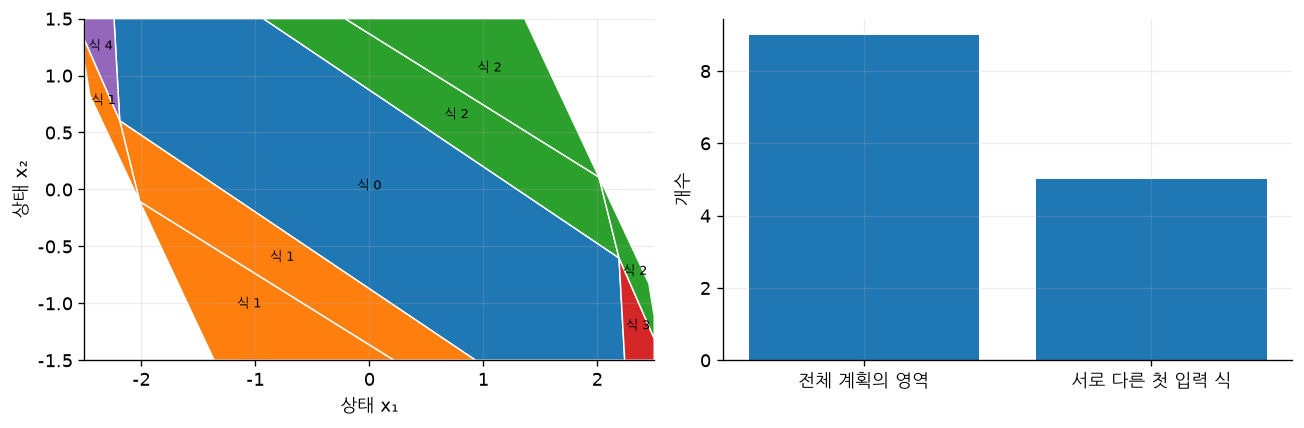

In [19]:
laws = []
law_index = []
for region in regions:
    coef = np.r_[region["K"][0], region["k"][0]]
    ids = [
        i
        for i, other in enumerate(laws)
        if np.allclose(coef, other, rtol=0, atol=1e-10)
    ]
    if not ids:
        ids = [len(laws)]
        laws.append(coef)
    law_index.append(ids[0])


def shared_first(x):
    x = state_vector(x)
    for i, region in enumerate(regions):
        if np.max(region["Ar"] @ x - region["br"]) <= 2e-8:
            coef = laws[law_index[i]]
            return float(coef[:2] @ x + coef[2])
    raise ValueError("계산된 실행 가능 영역 밖의 상태입니다.")


reuse_error = max(abs(shared_first(x) - explicit(x)[0]) for x in samples if matching(x))
assert len(laws) < len(regions)
fig, axs = plt.subplots(1, 2, figsize=(11, 3.7))
for i, region in enumerate(regions):
    axs[0].add_patch(
        Polygon(
            region["poly"],
            facecolor=plt.cm.tab10(law_index[i]),
            edgecolor="white",
            lw=0.9,
        )
    )
    axs[0].text(
        *np.mean(region["poly"], axis=0), f"식 {law_index[i]}", ha="center", fontsize=8
    )
axs[0].set(xlim=(-2.5, 2.5), ylim=(-1.5, 1.5), xlabel="상태 x₁", ylabel="상태 x₂")
axs[1].bar(["전체 계획의 영역", "서로 다른 첫 입력 식"], [len(regions), len(laws)])
axs[1].set(ylabel="개수")
record("재사용 가능한 서로 다른 첫 입력 식 수", len(laws))
record("첫 입력 식 재사용 최대 오차", reuse_error, 1e-10)
savefig(fig, "shared_first_law")


## 7.10 Notes — 관련 연구와 읽기 안내

**교재 인쇄 pp.483**

교재는 파라미터 최적화의 민감도 분석에서 명시적 MPC로 이어지는 연구 흐름을 정리합니다. KKT를 사용하는 접근과 극 원뿔을 사용하는 기하 접근은 같은 최적성 구조를 다른 관점에서 설명합니다. 구간별 이차계획법은 DP 연결에 필요합니다.

이 자료는 2017년 교재의 서술을 따릅니다. 당시 참고문헌의 도구·알고리즘 설명을 현재 성능 비교나 최신 도구 추천으로 해석하지 않습니다. 더 읽을 때는 교재 pp.489–490의 장 참고문헌과 §7.9–7.10의 연결을 참고하세요.

## 7.11 Exercises — 연습문제와 추가 탐구

**교재 인쇄 pp.484–488**

교재 연습문제 7.1–7.3은 등식 제약 QP, 파라미터 등식 QP, 예측 상태·입력의 행렬 표현을 다룹니다. 아래는 이를 이해하기 위한 별도 수치 확인입니다. 교재 전체 연습문제의 해답을 제공하지 않습니다.

**추가 탐구**
1. 입력 한계를 줄여 실제 영역 수·실행 가능 집합·제어법칙이 어떻게 바뀌는지 비교하세요.
2. 전체 입력 열의 아핀 식은 다르지만 첫 입력 식은 같은 영역을 찾아보세요.
3. DP의 입력 제한을 바꾸고 직접 QP와의 일치를 다시 검증하세요.
4. 비유일 LP에 아주 작은 이차 비용을 더하면 선택되는 해와 원래 문제가 어떻게 달라지는지 설명하세요.
5. 종단 제약을 제거했을 때 이동 후보의 실행 가능성 논증에서 어떤 조건을 다시 검토해야 할지 적어보세요.
6. 상태 차원만으로 영역 수를 예측하기 어려운 이유를 활성 집합 관점에서 설명하세요.

**힌트:** 등식 QP는 KKT 선형 시스템을 풀고 입력 식을 비용에 대입합니다. 이차 정규화는 원래 LP를 그대로 푸는 것이 아니라 다른 목적함수를 정의합니다.

In [20]:
HH = np.array([[2.0, 0.2], [0.2, 1.0]])
FF = np.array([[1.0], [-0.5]])
EE = np.array([[1.0, 1.0]])
MM = np.block([[HH, EE.T], [EE, np.zeros((1, 1))]])
coeff = np.linalg.solve(MM, np.array([[-1.0, 0.0], [0.5, 0.0], [0.3, 1.0]]))
equality_errors = []
for x in (-2.0, -0.5, 0.0, 1.0, 2.0):
    sol = coeff @ np.array([x, 1.0])
    u = sol[:2]
    lam = sol[2:]
    equality_errors.extend(
        [
            np.max(abs(HH @ u + FF[:, 0] * x + EE.T @ lam)),
            abs((EE @ u)[0] - (0.3 * x + 1)),
        ]
    )
record("등식 QP KKT 잔차", max(equality_errors), 1e-12)
for name, v in CHECKS.items():
    print(f"{name}: {v:.9g}")
print("검증 지표 수:", len(CHECKS))
print(
    {
        "Python": sys.version.split()[0],
        "NumPy": np.__version__,
        "SciPy": scipy.__version__,
        "Matplotlib": matplotlib.__version__,
        "CVXPY": cp.__version__,
    }
)


스칼라 QP 입력 오차: 2.44514093e-06
종단 리아푸노프 등식 잔차: 2.22044605e-16
기하 예제 정지 잔차: 1.11022302e-16
실행 가능 판정 불일치 수: 0
전체 입력 열 QP 비교 최대 오차: 9.54084393e-06
최적 비용 QP 비교 최대 오차: 1.19768195e-10
원래 부등식 위반: 1.33226763e-15
KKT 정지 잔차: 1.88737914e-15
검증 상태 수: 283
원본 7.11 QP 입력 비교 오차: 1.40820109e-06
원본 7.11 x=1의 최적 입력: 1.5
원본 7.12 전체 입력 QP 비교 오차: 3.36741701e-06
원본 7.12 최적 비용 비교 오차: 2.01954009e-11
공유 경계 입력 불일치: 1.66533454e-15
공유 경계 비용 불일치: 1.95399252e-14
공유 경계 검사 수: 30
원본 7.11 좌미분 검증 오차: 2.50106092e-06
원본 7.11 우미분 검증 오차: 1.24955201e-06
종속 활성 KKT 행렬 계수: 2
폐루프 상태 비교 오차: 4.06321088e-11
폐루프 입력 비교 오차: 8.12642176e-11
단계 비용을 더한 비용 증가: 0
폐루프 입력 제한 위반: 0
폐루프 최종 상태 노름: 1.16066547e-06
DP 입력 QP 비교 최대 오차: 4.48359244e-06
DP 비용 QP 비교 최대 오차: 9.63806812e-11
DP 조각 경계 불일치: 8.8817842e-16
비유일 LP 마지막 비용 오차: 0
정규화 QP 해 비교 최대 오차: 1.08450723e-06
정규화 ε=1 δ=0.1의 원래 LP 비용 손실: 0.045
유일 LP 아핀 해 비교 오차: 0
노름 MPC 입력 비교 오차: 0
노름 MPC 비용 비교 오차: 0
실제 임계 영역 수: 9
열거 활성 후보 수: 79
재사용 가능한 서로 다른 첫 입력 식 수: 5
첫 입력 식 재사용 최대 오차: 2.22044605e-16
등식 QP KKT 잔차

## 참고 자료

Rawlings, Mayne, Diehl (2017), *Model Predictive Control: Theory, Computation, and Design*, 2판 1쇄, Chapter 7, pp.451–490. 원본 예제 7.11·7.12를 재현하며, 민감도·정규화·계수 재사용 및 다른 모델은 구조를 설명하는 보충 실습입니다. 한글 그래프는 Google Fonts의 나눔고딕을 사용합니다.